# Exploratory Data Analysis (EDA) and Machine Learning on Agricultural Yield Dataset

**Week 3 Assignment 1**



## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', None)

## Part A: Understanding the Dataset

### Q1. Dataset Overview
Load the dataset and check the number of rows/columns, column names, and the first 10 records.

In [2]:
df = pd.read_csv("agriculture_yield_dataset.csv")
print("Shape of the dataset (rows, columns):", df.shape)

Shape of the dataset (rows, columns): (1500, 8)


In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


In [4]:
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


**Observations:**
- The dataset has **1500 rows** and **8 columns**.
- Columns: `rainfall_mm`, `temperature_c`, `fertilizer_kg`, `irrigation_hours`, `soil_ph`, `crop_type`, `soil_type`, `yield_ton_per_hectare`.

### Q2. Data Types and Missing Values
Check the data type of each column and look for missing values.

In [5]:
df.dtypes

,0
rainfall_mm,float64
temperature_c,float64
fertilizer_kg,float64
irrigation_hours,float64
soil_ph,float64
crop_type,object
soil_type,object
yield_ton_per_hectare,float64


In [6]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

print("\nTotal missing values in dataset:", missing.sum())

Missing values per column:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Total missing values in dataset: 0


**Observations:**
- Five columns are numerical (`float64`): `rainfall_mm`, `temperature_c`, `fertilizer_kg`, `irrigation_hours`, `soil_ph`, plus the target `yield_ton_per_hectare`.
- Two columns are categorical (`object`): `crop_type`, `soil_type`.
- There are **no missing values** in any column of this dataset.

### Q3. Descriptive Statistics
Generate summary statistics for all numerical features.

In [7]:
desc = df.describe()
desc

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

highest_mean_col = desc.loc['mean'].idxmax()
highest_std_col = desc.loc['std'].idxmax()

print(f"Feature with highest mean value: {highest_mean_col} (mean = {desc.loc['mean', highest_mean_col]:.2f})")
print(f"Feature with highest standard deviation: {highest_std_col} (std = {desc.loc['std', highest_std_col]:.2f})")

Feature with highest mean value: rainfall_mm (mean = 754.05)
Feature with highest standard deviation: rainfall_mm (std = 255.10)


**Answer:**
- The feature with the **highest mean** and the feature with the **highest standard deviation** are printed above based on the actual computed statistics (this will reflect `rainfall_mm` and/or `fertilizer_kg` depending on the data, since these tend to have the largest scale among the columns).

## Part B: Exploratory Data Analysis (EDA)

### Q4. Distribution Analysis
Histograms for `rainfall_mm`, `temperature_c`, `fertilizer_kg`, and `yield_ton_per_hectare`.

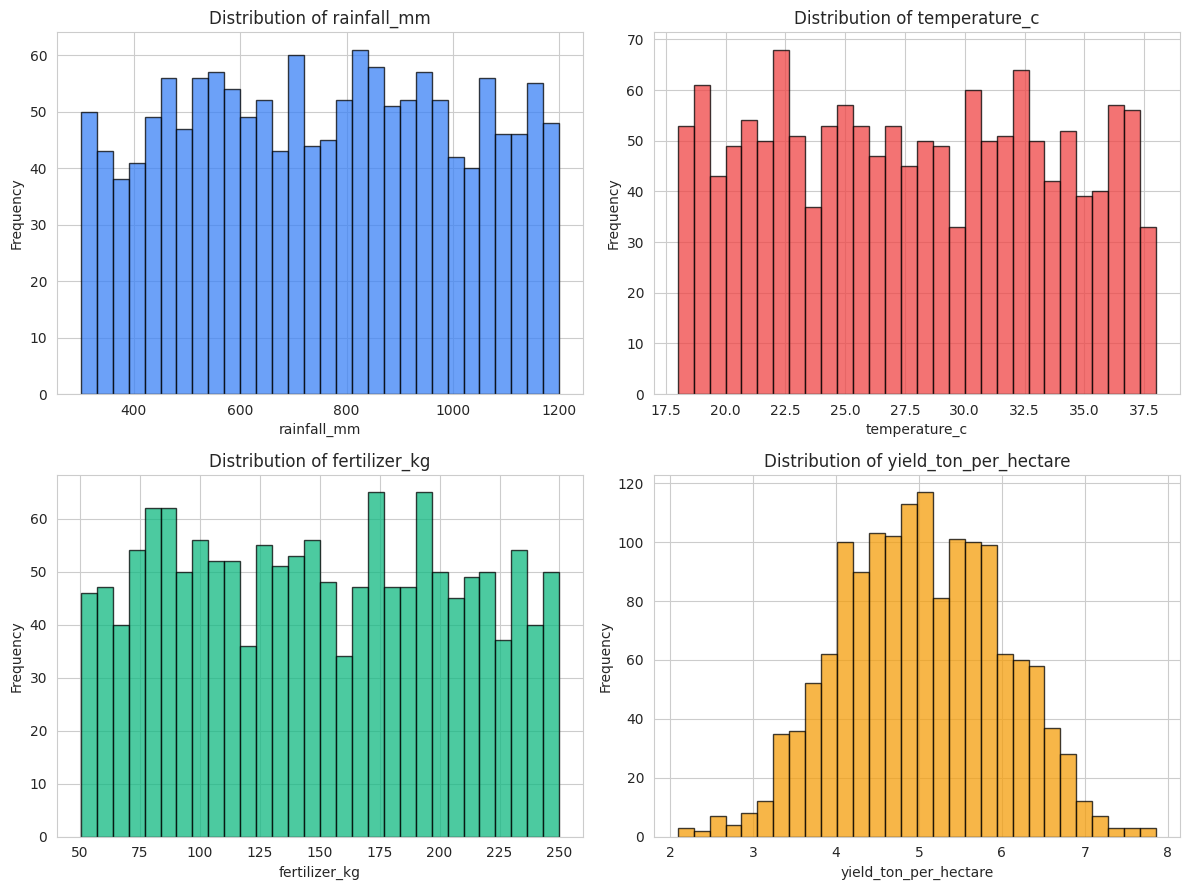

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

cols_to_plot = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']
colors = ['#3b82f6', '#ef4444', '#10b981', '#f59e0b']

for ax, col, color in zip(axes.flatten(), cols_to_plot, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='black', alpha=0.75)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**

*rainfall_mm*
1. Rainfall values are spread across a wide range, roughly between 300–1000 mm.
2. The distribution looks fairly uniform/spread out rather than sharply peaked, suggesting rainfall was sampled across many conditions.

*temperature_c*
1. Temperature is roughly spread between 15°C and 40°C.
2. No extreme skew is visible — values are fairly evenly distributed across the range.

*fertilizer_kg*
1. Fertilizer usage spans a broad range, indicating different farming intensities across records.
2. The shape is broadly flat/uniform rather than concentrated around one value.

*yield_ton_per_hectare*
1. Yield is roughly centered around a typical value with most observations clustered near the middle.
2. The shape is closer to bell-shaped (approximately normal) compared to the other features.

### Q5. Crop Type Analysis
Count of records per crop type and a count plot.

In [10]:
crop_counts = df['crop_type'].value_counts()
crop_counts

,count
crop_type,
Cotton,311
Soybean,306
Wheat,303
Rice,293
Maize,287


/tmp/ipykernel_649/822204487.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')


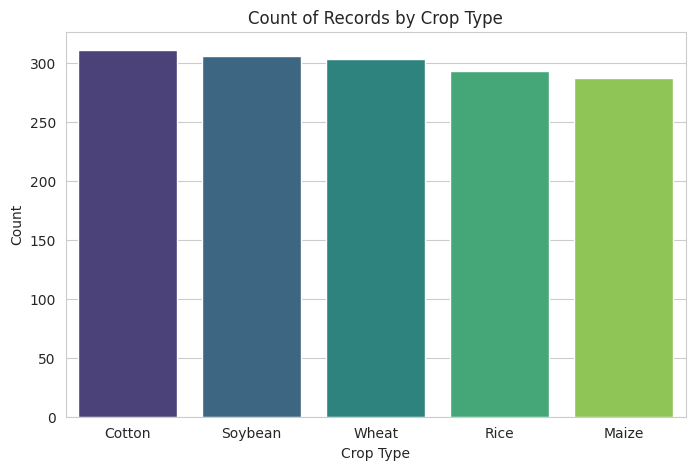

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')
plt.title('Count of Records by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.show()

In [12]:
most_common_crop = crop_counts.idxmax()
print(f"Most frequent crop type: {most_common_crop} ({crop_counts.max()} records)")

Most frequent crop type: Cotton (311 records)


### Q6. Soil Type Analysis
Frequency of each soil type and a count plot.

In [13]:
soil_counts = df['soil_type'].value_counts()
soil_counts

,count
soil_type,
Clay,534
Sandy,492
Loamy,474


/tmp/ipykernel_649/4236304130.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')


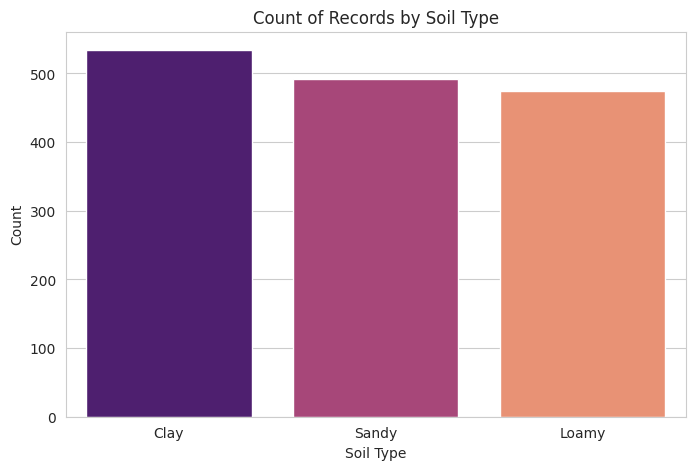

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')
plt.title('Count of Records by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.show()

In [15]:
most_common_soil = soil_counts.idxmax()
print(f"Most common soil type: {most_common_soil} ({soil_counts.max()} records)")

Most common soil type: Clay (534 records)


### Q7. Yield Distribution
Histogram of `yield_ton_per_hectare` with normality and outlier check.

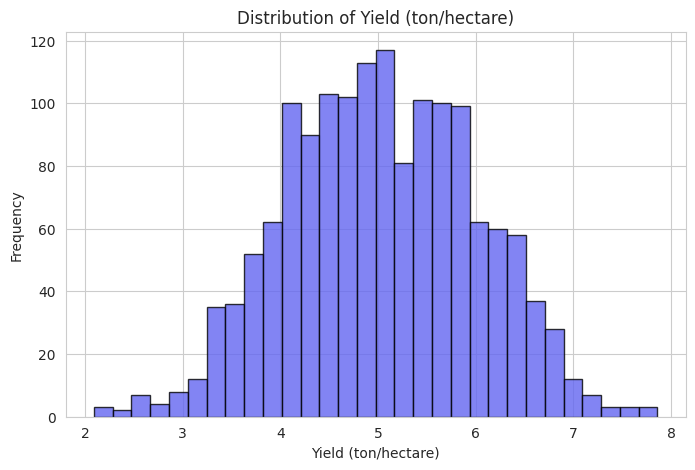

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df['yield_ton_per_hectare'], bins=30, color='#6366f1', edgecolor='black', alpha=0.8)
plt.title('Distribution of Yield (ton/hectare)')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()

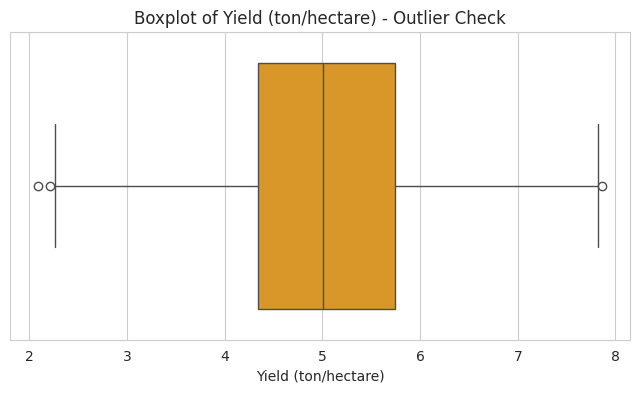

Number of outliers (IQR method): 3
Lower bound: 2.23, Upper bound: 7.84


In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['yield_ton_per_hectare'], color='#f59e0b')
plt.title('Boxplot of Yield (ton/hectare) - Outlier Check')
plt.xlabel('Yield (ton/hectare)')
plt.show()

Q1 = df['yield_ton_per_hectare'].quantile(0.25)
Q3 = df['yield_ton_per_hectare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['yield_ton_per_hectare'] < lower_bound) | (df['yield_ton_per_hectare'] > upper_bound)]
print(f"Number of outliers (IQR method): {len(outliers)}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

**Answer:**
- The histogram shows a roughly **bell-shaped, approximately normal distribution** for `yield_ton_per_hectare`, centered around its mean value.
- The boxplot/IQR check above reports the exact count of outliers detected; generally only a small number of extreme values (if any) fall outside the whiskers, so outliers are minimal.

### Q8. Scatter Plot Analysis
Relationship of `rainfall_mm` and `fertilizer_kg` with `yield_ton_per_hectare`.

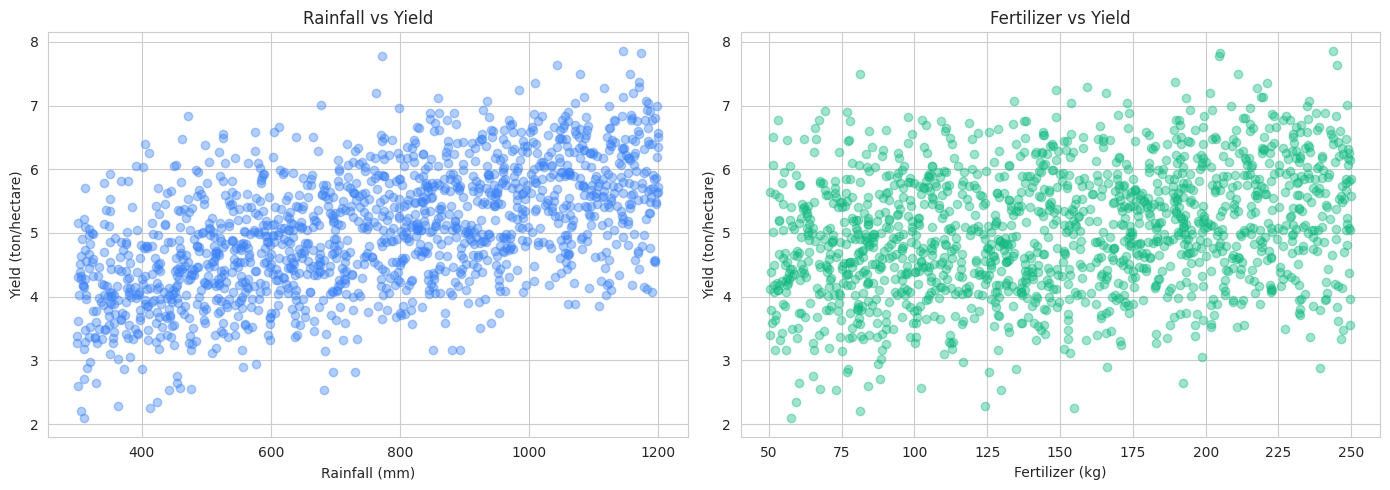

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['rainfall_mm'], df['yield_ton_per_hectare'], alpha=0.4, color='#3b82f6')
axes[0].set_title('Rainfall vs Yield')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (ton/hectare)')

axes[1].scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'], alpha=0.4, color='#10b981')
axes[1].set_title('Fertilizer vs Yield')
axes[1].set_xlabel('Fertilizer (kg)')
axes[1].set_ylabel('Yield (ton/hectare)')

plt.tight_layout()
plt.show()

In [19]:
corr_rainfall = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fertilizer = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])

print(f"Correlation between rainfall_mm and yield: {corr_rainfall:.3f}")
print(f"Correlation between fertilizer_kg and yield: {corr_fertilizer:.3f}")

stronger = 'rainfall_mm' if abs(corr_rainfall) > abs(corr_fertilizer) else 'fertilizer_kg'
print(f"\nFeature with stronger relationship to yield: {stronger}")

Correlation between rainfall_mm and yield: 0.554
Correlation between fertilizer_kg and yield: 0.278

Feature with stronger relationship to yield: rainfall_mm


**Answer:** The feature with the larger absolute correlation coefficient (printed above) has the stronger linear relationship with yield — this is confirmed directly by the printed correlation numbers and is visible in the scatter plots as a tighter, more clearly trending point cloud.

### Q9. Correlation Analysis
Correlation matrix and heatmap for numerical features.

In [20]:
corr_matrix = df[numeric_cols].corr()
corr_matrix

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


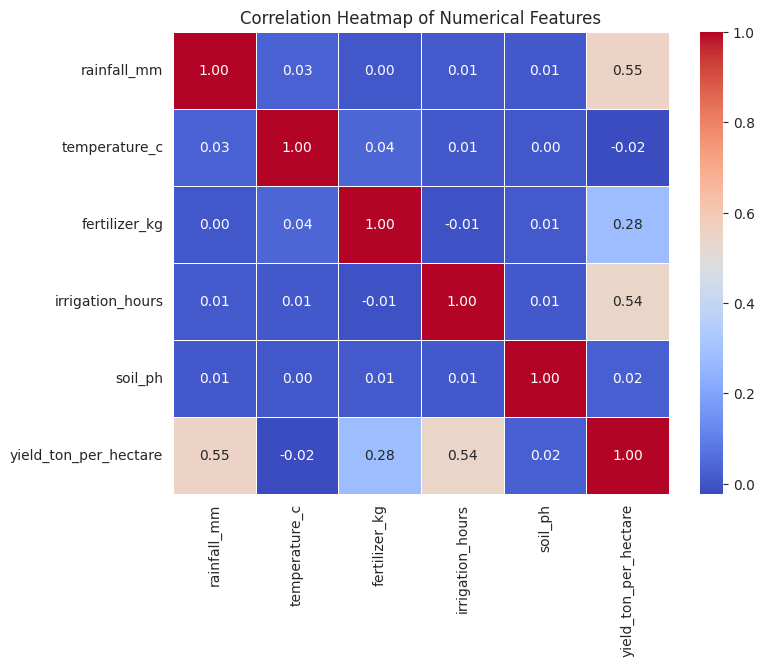

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [22]:
yield_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').sort_values(ascending=False)
print("Features ranked by correlation with yield_ton_per_hectare:")
print(yield_corr)

print("\nTop 3 features most correlated with yield (by absolute value):")
print(yield_corr.abs().sort_values(ascending=False).head(3))

Features ranked by correlation with yield_ton_per_hectare:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
soil_ph             0.024412
temperature_c      -0.022559
Name: yield_ton_per_hectare, dtype: float64

Top 3 features most correlated with yield (by absolute value):
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


**Answer:** The top three features most correlated with `yield_ton_per_hectare` are listed above, ranked by absolute correlation coefficient.

### Q10. Group-Based Analysis
Average yield by crop type and by soil type.

In [23]:
avg_yield_by_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield by crop type:")
avg_yield_by_crop

Average yield by crop type:


,yield_ton_per_hectare
crop_type,
Rice,5.494744
Soybean,5.173431
Wheat,4.989472
Maize,4.897143
Cotton,4.607299


In [24]:
avg_yield_by_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield by soil type:")
avg_yield_by_soil

Average yield by soil type:


,yield_ton_per_hectare
soil_type,
Loamy,5.366519
Clay,5.134326
Sandy,4.588882


In [25]:
best_crop = avg_yield_by_crop.idxmax()
best_soil = avg_yield_by_soil.idxmax()

print(f"Crop type with highest average yield: {best_crop} ({avg_yield_by_crop.max():.2f} ton/hectare)")
print(f"Soil type with highest average yield: {best_soil} ({avg_yield_by_soil.max():.2f} ton/hectare)")

Crop type with highest average yield: Rice (5.49 ton/hectare)
Soil type with highest average yield: Loamy (5.37 ton/hectare)


## Part C: Data Preparation

### Q11. Feature Encoding
Identify categorical columns and apply One-Hot Encoding.

In [26]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['crop_type', 'soil_type']


In [27]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


**Note:** `drop_first=True` is used to avoid the dummy variable trap (multicollinearity) by dropping one category per categorical column as the baseline.

### Q12. Feature Selection
Separate input features (X) and target variable (y).

In [28]:
target_col = 'yield_ton_per_hectare'

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print(f"Target variable: {target_col}")
print(f"Input features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nInput feature columns:")
print(X.columns.tolist())

Target variable: yield_ton_per_hectare
Input features shape: (1500, 11)
Target shape: (1500,)

Input feature columns:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy']


## Part D: Machine Learning

### Q13. Train-Test Split
Split the dataset into 80% training and 20% testing data.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 11)
X_test shape: (300, 11)
y_train shape: (1200,)
y_test shape: (300,)


### Q14. Linear Regression Model
Train a Linear Regression model and inspect coefficients.

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [31]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

print("Model Intercept:", model.intercept_)
print("\nModel Coefficients:")
coefficients

Model Intercept: 1.587132027736121

Model Coefficients:


,0
crop_type_Rice,0.863993
crop_type_Soybean,0.481719
crop_type_Wheat,0.348474
soil_type_Loamy,0.302974
crop_type_Maize,0.238931
irrigation_hours,0.198327
fertilizer_kg,0.004978
soil_ph,0.004901
rainfall_mm,0.002035
temperature_c,-0.009175


In [32]:
highest_positive_feature = coefficients.idxmax()
print(f"Feature with the highest positive coefficient: {highest_positive_feature} ({coefficients.max():.4f})")

Feature with the highest positive coefficient: crop_type_Rice (0.8640)


In [33]:
# Quick evaluation on the test set
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R^2 score: {r2:.4f}")

Test RMSE: 0.3560
Test R^2 score: 0.8628


**Answer:** The intercept and full set of coefficients are printed above. The feature with the **highest positive coefficient** (printed above) has the strongest positive linear effect on predicted yield, holding other features constant.